In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




# IMPORT DATA

In [2]:
df = pd.read_csv('IMDB Dataset.csv' ) 

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [7]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

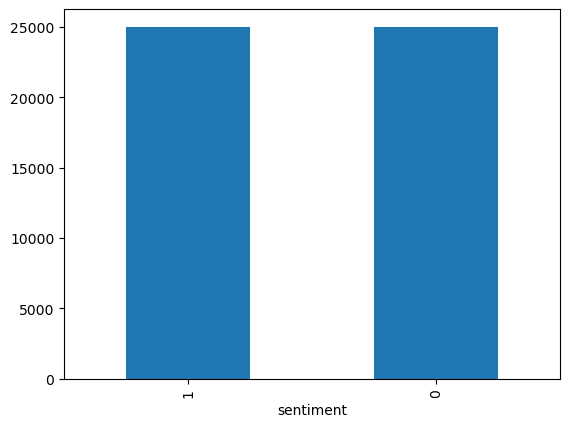

In [37]:
df.sentiment.value_counts().plot(kind='bar')
plt.show()

In [38]:
df.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)

In [39]:
df["sentiment"].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

In [42]:
from sklearn.model_selection import train_test_split
train, temp = train_test_split(df, test_size=0.20, random_state=42, stratify=df['sentiment'])
val, test = train_test_split(temp, test_size=0.50, random_state=42, stratify=temp['sentiment'])
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 40000, Val: 5000, Test: 5000


In [43]:
train_data = train
val_data = val
test_data = test

In [44]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [45]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


# Tokenize text data
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_data["review"])
# Convert text to sequences and pad
X_train = pad_sequences(tokenizer.texts_to_sequences(train_data["review"]), maxlen=200)
X_val = pad_sequences(tokenizer.texts_to_sequences(val_data["review"]), maxlen=200)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_data["review"]), maxlen=200)

# Target variables
Y_train = train_data["sentiment"].values
Y_val = val_data["sentiment"].values
Y_test = test_data["sentiment"].values

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from zipfile import ZipFile

model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=128, input_length=200))
model.add(LSTM(units=64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping]
)

model.summary()

Epoch 1/10


C:\Users\Deba123\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 138ms/step - accuracy: 0.7344 - loss: 0.5236 - val_accuracy: 0.8538 - val_loss: 0.3465
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 141ms/step - accuracy: 0.8463 - loss: 0.3615 - val_accuracy: 0.8706 - val_loss: 0.3180
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 147ms/step - accuracy: 0.8693 - loss: 0.3187 - val_accuracy: 0.8750 - val_loss: 0.3017
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 142ms/step - accuracy: 0.8945 - loss: 0.2669 - val_accuracy: 0.8780 - val_loss: 0.3039
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 147ms/step - accuracy: 0.9057 - loss: 0.2387 - val_accuracy: 0.8678 - val_loss: 0.3135
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.9160 - loss: 0.2165 - val_accuracy: 0.8834 - val_loss: 0.2999
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 143ms/step - accuracy: 0.9253 - loss: 0.1916 - val_accuracy: 0.8726 - val_loss: 0.3481
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 147ms/step - accuracy: 0.9324 - loss: 0.1776 - val

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (64, 200, 128)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (64, 64)               │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (64, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,068,421 (7.89 MB)

 Trainable params: 689,473 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,378,948 (5.26 MB)

In [47]:
model.save("sentiment_lstm_model.keras")


In [48]:
from tensorflow.keras.models import load_model

model = load_model("sentiment_lstm_model.keras")

loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Model Loss: {loss:.4f}")
print(f"Model Accuracy: {accuracy:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8894 - loss: 0.2885
Model Loss: 0.3076
Model Accuracy: 0.8824


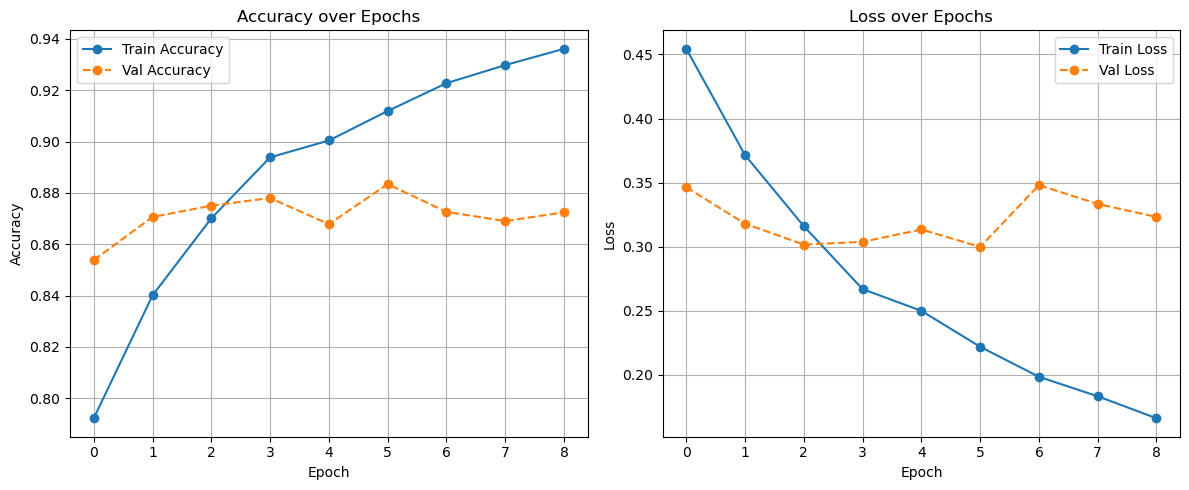

In [49]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', linestyle='--', marker='o')  # Dotted line
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--', marker='o')  # Dotted line
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step


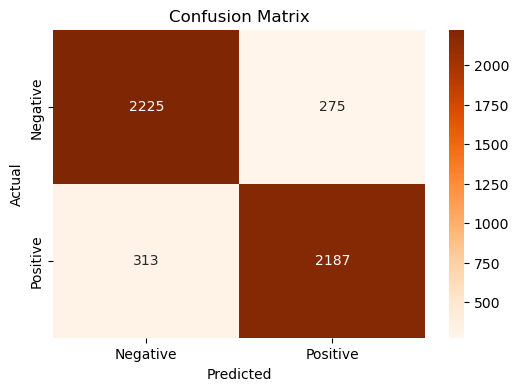

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [51]:
def predict_sentiment(review):
    # Preprocess the review
    review = review.lower().strip()
    # Tokenize and pad
    sequence = tokenizer.texts_to_sequences([review])
    padded_sequence = pad_sequences(sequence, maxlen=200)
    # Predict sentiment
    prediction = model.predict(padded_sequence)
    prob = prediction[0][0]
    sentiment = "positive" if prob > 0.5 else "negative"
    return sentiment, prob

In [52]:
new_review = "This movie was amazing, I loved it so much!"
sentiment, confidence = predict_sentiment(new_review)
print(f"The sentiment is: {sentiment} (confidence: {confidence:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
The sentiment is: positive (confidence: 0.99)


In [53]:
new_review = "This movie was average for others, but I really loved it!"
sentiment, confidence = predict_sentiment(new_review)
print(f"The sentiment is: {sentiment} (confidence: {confidence:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
The sentiment is: positive (confidence: 0.90)


In [54]:
new_review = "Disgusting."
sentiment, confidence = predict_sentiment(new_review)
print(f"The sentiment of the review is: {sentiment} (confidence: {confidence:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
The sentiment of the review is: negative (confidence: 0.12)
